# 02 · Senate order flow

The return notebook showed a clear **Senate** price effect. Here we ask the next question:
**who is buying?** We look at retail order flow (BJZZ-Barber trades) and at the residual
non-retail flow.

**Main result:** the price moves, but order flow does **not**. Both order-flow measures stay
near zero around the disclosure. Run `00_build_panel.ipynb` first.

In [1]:
import sys
from pathlib import Path

here = Path.cwd()
ROOT = here if (here / "helpers.py").exists() else here.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from config import TABLE_DIR, FIGURE_DIR, LICENSED_DATA
from helpers import (load_work_panel, load_quiver, trading_days, purchase_events,
                     collapse_cells, event_flag, run_panel, run_event_time,
                     senate_buckets, run_split, add_orderflow_extras, coef)

In [2]:
panel = load_work_panel()
quiver = load_quiver()
days = trading_days(panel)
pidx = pd.MultiIndex.from_frame(panel[["ticker", "date"]])

# Senate purchase rows, the treated cells, and the salience/moderator tags.
senate_rows = purchase_events(quiver, "senate", days)
senate = collapse_cells(senate_rows)
buckets = senate_buckets(senate_rows, days)
print("Senate treated cells:", len(senate))

Senate treated cells: 1419


## Order-flow windows

Abnormal retail and residual OIB over event windows. Retail OIB uses only days with some
retail activity. Every coefficient is close to zero and insignificant.

In [3]:
rows = []
for measure, dep, drop_zero in [("Abn. retail OIB", "abn_retail_oib", True),
                                ("Abn. residual OIB", "abn_nonretail_oib", False)]:
    for w in [0, 1, 3, 5, 10]:
        panel["flag"] = event_flag(pidx, senate, days, window=w)
        res = run_panel(panel, dep, ["flag"], drop_zero_retail=drop_zero)
        rows.append({"measure": measure, "window": f"[0,+{w}]",
                     "treated_rows": int(panel["flag"].sum()),
                     "coef": round(res.params["flag"], 5),
                     "se": round(res.std_errors["flag"], 5),
                     "p": round(res.pvalues["flag"], 3)})

oib_windows = pd.DataFrame(rows)
oib_windows.to_csv(TABLE_DIR / "senate_oib_windows.csv", index=False)
oib_windows

,measure,window,treated_rows,coef,se,p
0,Abn. retail OIB,"[0,+0]",1080,-0.00206,0.00512,0.688
1,Abn. retail OIB,"[0,+1]",2151,-0.00038,0.00390,0.923
2,Abn. retail OIB,"[0,+3]",4276,-0.00092,0.00312,0.768
3,Abn. retail OIB,"[0,+5]",6283,-0.00072,0.00281,0.798
4,Abn. retail OIB,"[0,+10]",11518,0.00187,0.00225,0.405
5,Abn. residual OIB,"[0,+0]",1080,-0.00119,0.00329,0.717
6,Abn. residual OIB,"[0,+1]",2151,0.00016,0.00267,0.954
7,Abn. residual OIB,"[0,+3]",4276,-0.00115,0.00216,0.595
8,Abn. residual OIB,"[0,+5]",6283,-0.00038,0.00197,0.847
9,Abn. residual OIB,"[0,+10]",11518,-0.00038,0.00164,0.816


## Event-time figure

Return and order-flow coefficients on each event day `k`. The return jumps on day 0, but
neither order-flow series shows a matching buy-side jump.

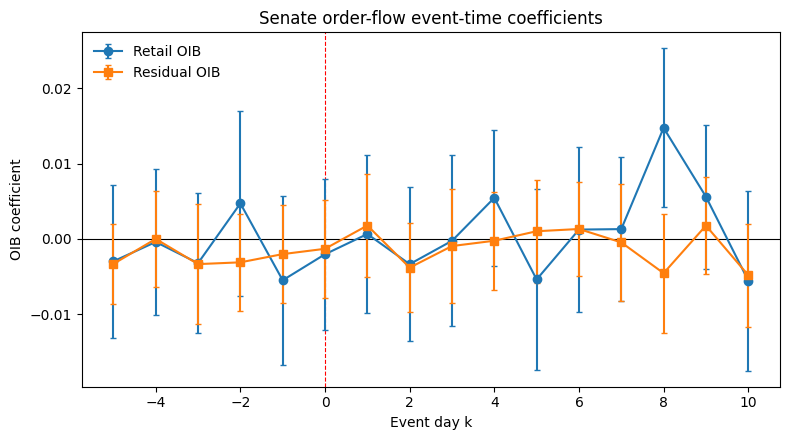

In [4]:
ret_et = run_event_time(panel, "crsp_ret", pidx, senate, days)
retail_et = run_event_time(panel, "abn_retail_oib", pidx, senate, days, drop_zero_retail=True)
resid_et = run_event_time(panel, "abn_nonretail_oib", pidx, senate, days)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="red", linewidth=0.8, linestyle="--")
ax.errorbar(retail_et["k"], retail_et["coef"], yerr=1.96 * retail_et["se"], fmt="o-", capsize=2, label="Retail OIB")
ax.errorbar(resid_et["k"], resid_et["coef"], yerr=1.96 * resid_et["se"], fmt="s-", capsize=2, label="Residual OIB")
ax.set_xlabel("Event day k")
ax.set_ylabel("OIB coefficient")
ax.set_title("Senate order-flow event-time coefficients")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fig_senate_orderflow_event_time.png", dpi=200)
plt.show()

The numbers behind the figure, with the day-0 return for comparison. Returns react; OIB does not.

In [5]:
combined = ret_et[["k", "coef_bps", "p"]].rename(columns={"coef_bps": "return_bps", "p": "return_p"})
combined = combined.merge(retail_et[["k", "coef", "p"]].rename(columns={"coef": "retail_oib", "p": "retail_p"}), on="k")
combined = combined.merge(resid_et[["k", "coef", "p"]].rename(columns={"coef": "resid_oib", "p": "resid_p"}), on="k")
combined = combined.round({"return_bps": 2, "return_p": 3, "retail_oib": 5, "retail_p": 3, "resid_oib": 5, "resid_p": 3})
combined.to_csv(TABLE_DIR / "senate_orderflow_event_time.csv", index=False)
combined

,k,return_bps,return_p,retail_oib,retail_p,resid_oib,resid_p
0,-5,-25.43,0.024,-0.00297,0.568,-0.00332,0.222
1,-4,-14.60,0.216,-0.00040,0.935,0.00000,0.999
2,-3,-0.46,0.958,-0.00322,0.499,-0.00335,0.413
3,-2,2.51,0.792,0.00472,0.451,-0.00311,0.345
4,-1,9.83,0.198,-0.00549,0.338,-0.00202,0.544
5,0,24.58,0.007,-0.00204,0.691,-0.00131,0.693
6,1,15.88,0.111,0.00065,0.903,0.00178,0.610
7,2,0.43,0.968,-0.00335,0.520,-0.00382,0.206
8,3,-1.14,0.917,-0.00025,0.965,-0.00094,0.806
9,4,22.23,0.033,0.00546,0.234,-0.00024,0.942


## Salience splits

Is the response stronger for disclosures that are easier to notice? We split the `[0,+1]`
results by committee relevance, disclosed trade size, and election timing. The retail OIB
column is what the salience hypotheses predict, and it stays insignificant everywhere.

In [6]:
deps = [("crsp_ret", False), ("abn_retail_oib", True), ("abn_nonretail_oib", False)]

salience = pd.concat([
    run_split(panel, pidx, buckets, days, "committee", ["committee", "noncommittee", "unclassified"], deps),
    run_split(panel, pidx, buckets, days, "size_bucket", ["small", "mid", "large"], deps),
    run_split(panel, pidx, buckets, days, "election_bucket", ["election", "nonelection"], deps),
], ignore_index=True)
salience.to_csv(TABLE_DIR / "senate_salience_splits.csv", index=False)
salience

,split,category,outcome,treated_rows,coef,p,coef_bps
0,committee,committee,crsp_ret,516,0.000148,0.8930,1.48
1,committee,noncommittee,crsp_ret,1581,0.002573,0.0021,25.73
2,committee,unclassified,crsp_ret,54,0.004053,0.2721,40.53
3,committee,committee,abn_retail_oib,516,0.004373,0.6599,43.73
4,committee,noncommittee,abn_retail_oib,1581,-0.001309,0.7542,-13.09
5,committee,unclassified,abn_retail_oib,54,-0.018066,0.3913,-180.66
6,committee,committee,abn_nonretail_oib,516,0.007563,0.1543,75.63
7,committee,noncommittee,abn_nonretail_oib,1581,-0.001624,0.6111,-16.24
8,committee,unclassified,abn_nonretail_oib,54,-0.017739,0.0966,-177.39
9,size_bucket,small,crsp_ret,1373,0.001313,0.1407,13.13


## Top-senator channel check

Maybe a few well-known senators drive the result. We take the five senators with the largest
return contribution (ranked on returns only, in `senator_return_influence.csv`) and re-run the
test. The return effect gets **stronger**, but order flow still shows nothing.

In [7]:
influence = pd.read_csv(LICENSED_DATA / "senator_return_influence.csv")
top5 = influence.sort_values("influence_bps", ascending=False).head(5)["member_id"].tolist()
top5_min20 = (influence[influence["treated_rows_member"] >= 20]
              .sort_values("influence_bps", ascending=False).head(5)["member_id"].tolist())

def group_check(member_ids, label):
    in_group = senate_rows["BioGuideID"].isin(member_ids)
    group_cells = collapse_cells(senate_rows[in_group])
    other_cells = collapse_cells(senate_rows[~in_group])
    panel["g"] = event_flag(pidx, group_cells, days, window=1)
    panel["o"] = event_flag(pidx, other_cells, days, window=1)
    out = {"group": label, "treated_rows": int(panel["g"].sum())}
    for name, dep, drop_zero in [("return_bps", "crsp_ret", False),
                                 ("retail_oib", "abn_retail_oib", True),
                                 ("resid_oib", "abn_nonretail_oib", False)]:
        res = run_panel(panel, dep, ["g", "o"], drop_zero_retail=drop_zero)
        scale = 10_000 if name == "return_bps" else 1
        out[name] = round(res.params["g"] * scale, 4)
        out[f"{name}_p"] = round(res.pvalues["g"], 3)
    return out

top_senator = pd.DataFrame([
    group_check(top5, "Top 5 by return contribution"),
    group_check(top5_min20, "Top 5, at least 20 rows"),
])
top_senator.to_csv(TABLE_DIR / "top_senator_channel.csv", index=False)
top_senator

,group,treated_rows,return_bps,return_bps_p,retail_oib,retail_oib_p,resid_oib,resid_oib_p
0,Top 5 by return contribution,880,51.8556,0.0,-0.0070,0.260,0.0006,0.896
1,"Top 5, at least 20 rows",904,48.1136,0.0,-0.0081,0.189,0.0003,0.942


## Appendix: additional moderators

More `[0,+1]` splits, now by party, filing freshness, and S&P 500 membership. The order-flow
null holds in every group.

In [8]:
moderators = pd.concat([
    run_split(panel, pidx, buckets, days, "party_bucket", ["democrat", "republican", "both"], deps),
    run_split(panel, pidx, buckets, days, "freshness", ["fresh", "stale"], deps),
    run_split(panel, pidx, buckets, days, "sp500_bucket", ["sp500", "nonsp500"], deps),
], ignore_index=True)
moderators.to_csv(TABLE_DIR / "senate_additional_moderators.csv", index=False)
moderators

,split,category,outcome,treated_rows,coef,p,coef_bps
0,party_bucket,democrat,crsp_ret,552,0.004063,0.0017,40.63
1,party_bucket,republican,crsp_ret,1585,0.001291,0.1307,12.91
2,party_bucket,both,crsp_ret,4,0.003893,0.8567,38.93
3,party_bucket,democrat,abn_retail_oib,552,-0.009259,0.1754,-92.59
4,party_bucket,republican,abn_retail_oib,1585,0.003558,0.4416,35.58
5,party_bucket,both,abn_retail_oib,4,0.010533,0.8100,105.33
6,party_bucket,democrat,abn_nonretail_oib,552,0.003783,0.3614,37.83
7,party_bucket,republican,abn_nonretail_oib,1585,-0.001134,0.7232,-11.34
8,party_bucket,both,abn_nonretail_oib,4,0.088902,0.1649,889.02
9,freshness,fresh,crsp_ret,554,0.003111,0.0284,31.11


## Appendix: OIB measurement sensitivity

Does the null depend on how we measure OIB? We repeat the `[0,+1]` test with raw OIB levels
and with three different pre-disclosure baseline windows. The result barely moves.

In [9]:
ext = add_orderflow_extras(panel)
ext["flag"] = event_flag(pidx, senate, days, window=1)

rows = []
measures = [("Abnormal (main)", "abn_retail_oib", "abn_nonretail_oib"),
            ("Raw level", "retail_oib", "nonretail_oib"),
            ("Baseline w10/g5", "abn_retail_oib_w10_g5", "abn_nonretail_oib_w10_g5"),
            ("Baseline w20/g6", "abn_retail_oib_w20_g6", "abn_nonretail_oib_w20_g6"),
            ("Baseline w30/g5", "abn_retail_oib_w30_g5", "abn_nonretail_oib_w30_g5")]
for measure, retail_dep, resid_dep in measures:
    r = run_panel(ext, retail_dep, ["flag"], drop_zero_retail=True)
    s = run_panel(ext, resid_dep, ["flag"], drop_zero_retail=False)
    rows.append({"measure": measure,
                 "retail_coef": round(r.params["flag"], 5), "retail_p": round(r.pvalues["flag"], 3),
                 "resid_coef": round(s.params["flag"], 5), "resid_p": round(s.pvalues["flag"], 3)})

oib_sensitivity = pd.DataFrame(rows)
oib_sensitivity.to_csv(TABLE_DIR / "senate_oib_measurement_sensitivity.csv", index=False)
oib_sensitivity

,measure,retail_coef,retail_p,resid_coef,resid_p
0,Abnormal (main),-0.00038,0.923,0.00016,0.954
1,Raw level,0.00106,0.781,-0.00053,0.827
2,Baseline w10/g5,0.00042,0.914,0.00047,0.868
3,Baseline w20/g6,-0.00045,0.907,0.00017,0.950
4,Baseline w30/g5,-0.00038,0.921,-0.00029,0.910


## Appendix: signed activity and net buying

A final check: maybe buying and selling both rise and cancel out in OIB. We look at signed
buy/sell shares and at net dollar buying scaled by normal volume. Still no clear increase.

In [10]:
outcomes = ["abn_retail_buy_share", "abn_retail_sell_share", "abn_unsigned_retail_share",
            "abn_retail_dollar_share", "abn_nonretail_buy_share", "abn_nonretail_sell_share",
            "abn_nonretail_dollar_share", "abn_retail_netbuy_scaled", "abn_nonretail_netbuy_scaled"]

rows = []
for w in [1, 5]:
    ext["flag"] = event_flag(pidx, senate, days, window=w)
    for dep in outcomes:
        res = run_panel(ext, dep, ["flag"], drop_zero_retail=False)
        rows.append({"window": f"[0,+{w}]", "outcome": dep,
                     "coef": round(res.params["flag"], 6), "p": round(res.pvalues["flag"], 3)})

activity = pd.DataFrame(rows)
activity.to_csv(TABLE_DIR / "senate_activity_outcomes.csv", index=False)
activity

,window,outcome,coef,p
0,"[0,+1]",abn_retail_buy_share,0.000045,0.889
1,"[0,+1]",abn_retail_sell_share,-0.000003,0.991
2,"[0,+1]",abn_unsigned_retail_share,-0.000075,0.880
3,"[0,+1]",abn_retail_dollar_share,0.000041,0.937
4,"[0,+1]",abn_nonretail_buy_share,-0.000693,0.542
5,"[0,+1]",abn_nonretail_sell_share,-0.001045,0.322
6,"[0,+1]",abn_nonretail_dollar_share,-0.000041,0.937
7,"[0,+1]",abn_retail_netbuy_scaled,0.000035,0.913
8,"[0,+1]",abn_nonretail_netbuy_scaled,0.001691,0.470
9,"[0,+5]",abn_retail_buy_share,0.000019,0.937
